# MAP-Elite (Gaussian + Line, Boltzmann Mix) — Baseline (Local)

**Method:** MAP-Elites with `PSEMut` + `PSELine` (Boltzmann Mix adaptive allocation)  
**Seeds:** 2 (42, 123)  
**Task:** Ant-v5 Unidirectional Gait (4D Gait BD, 10×10×10×10 = 10000 bins)  
**Budget:** N_TOTAL × N_STEPS = 1e5

In [ ]:
# ============================================================
# Cell 0: Install dependencies (run once, then restart kernel)
# ============================================================
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'cma', 'gymnasium[mujoco]', 'torch', 'numpy', 'pandas', 'matplotlib', '-q'])

0

In [ ]:
# ============================================================
# Cell 1: Setup — load SSLVE modules from local repo
# ============================================================
import sys, os, glob

SSLVE_PATH = os.path.expanduser('~/Downloads/org-Latent-Variable-Evolution 3/dev/SSLVE')
sys.path.insert(0, SSLVE_PATH)
for f in sorted(glob.glob(os.path.join(SSLVE_PATH, '*.py'))):
    exec(open(f).read())

print('Setup complete.')

Setup complete.


In [ ]:
# ============================================================
# Cell 2: Method Hyperparameters
# ============================================================
import numpy as np
import random
import torch

# --- Architecture ---
ARCHITECTURE     = [27, 64, 64, 8]  #@param
OUTPUT_ACTIVATION = 'tanh'  #@param {type:"string"}
MAX_STEPS        = 500   #@param {type:"integer"}
N_EPISODES       = 3     #@param {type:"integer"}
CTRL_COST_WEIGHT = 0.5   #@param {type:"number"}

# --- Gait BD Grid ---
BIN_SIZES        = [10, 10, 10, 10]  #@param

# --- Fitness ---
TOP_K            = 1     #@param {type:"integer"}
MAX_FITNESS      = 500.0 #@param {type:"number"}
GREEDY_MEM       = True  #@param {type:"boolean"}

# --- Mutation sigma ---
PSE_MUT_SIGMA    = 0.05  #@param {type:"number"}

# --- Boltzmann Mix ---
EMA_ALPHA        = 0.25  #@param {type:"number"}
TEMPERATURE      = 10    #@param {type:"number"}
MIN_PROPORTION   = 0.05  #@param {type:"number"}

# --- Search budget ---
N_TOTAL          = 500   #@param {type:"integer"}
N_STEPS          = 200   #@param {type:"integer"}

# --- Checkpoint base directory (local) ---
CKPT_BASE_DIR    = os.path.expanduser('~/Downloads/ant_gait_ckpts/Ant_MAPElite_GaussLine_BoltzMix/')

print(f'Method: MAP-Elite (Gaussian + Line, Boltzmann Mix)')
print(f'Architecture: {ARCHITECTURE}, Output: {OUTPUT_ACTIVATION}')
print(f'Gait BD: {BIN_SIZES} ({np.prod(BIN_SIZES)} bins)')
print(f'PSE_MUT_SIGMA={PSE_MUT_SIGMA}')
print(f'EMA_ALPHA={EMA_ALPHA}, TEMPERATURE={TEMPERATURE}, MIN_PROPORTION={MIN_PROPORTION}')
print(f'N_TOTAL={N_TOTAL}, N_STEPS={N_STEPS}')
print(f'Checkpoints will be saved to: {CKPT_BASE_DIR}')

Method: MAP-Elite (Gaussian + Line, Boltzmann Mix)
Architecture: [27, 64, 64, 8], Output: tanh
Gait BD: [10, 10, 10, 10] (10000 bins)
PSE_MUT_SIGMA=0.05
EMA_ALPHA=0.25, TEMPERATURE=10, MIN_PROPORTION=0.05
N_TOTAL=500, N_STEPS=200
Checkpoints will be saved to: /Users/frankh/Downloads/ant_gait_ckpts/Ant_MAPElite_GaussLine_BoltzMix/


Weight dim: 6472

========== seed=123 ==========

--- MAP-Elite Step 1/200 ---
  Operator ratio - pse_mut: 500/500 (100%), pse_line: 0/500 (0%)
Collecting: 500/500 [75s elapsed, 0s remaining]]
Archive: 117, Bins: 117, Coverage: 0.0117, Fitness min/mean/max: -98.76/-3.82/45.78
QD-score: 58946.8759

--- MAP-Elite Step 2/200 ---
  Operator ratio - pse_mut: 250/500 (50%), pse_line: 250/500 (50%)
Collecting: 500/500 [119s elapsed, 0s remaining]]
Archive: 304, Bins: 304, Coverage: 0.0304, Fitness min/mean/max: -140.32/-4.05/80.01
QD-score: 153231.7175

--- MAP-Elite Step 3/200 ---
  Operator ratio - pse_mut: 125/500 (25%), pse_line: 375/500 (75%)
Collecting: 500/500 [141s elapsed, 0s remaining]]
Archive: 485, Bins: 485, Coverage: 0.0485, Fitness min/mean/max: -140.32/-4.71/80.01
QD-score: 244786.6112

--- MAP-Elite Step 4/200 ---
  Operator ratio - pse_mut: 111/500 (22%), pse_line: 389/500 (78%)
Collecting: 500/500 [152s elapsed, 0s remaining]]
Archive: 663, Bins: 663, Coverage: 0.0663, Fitn

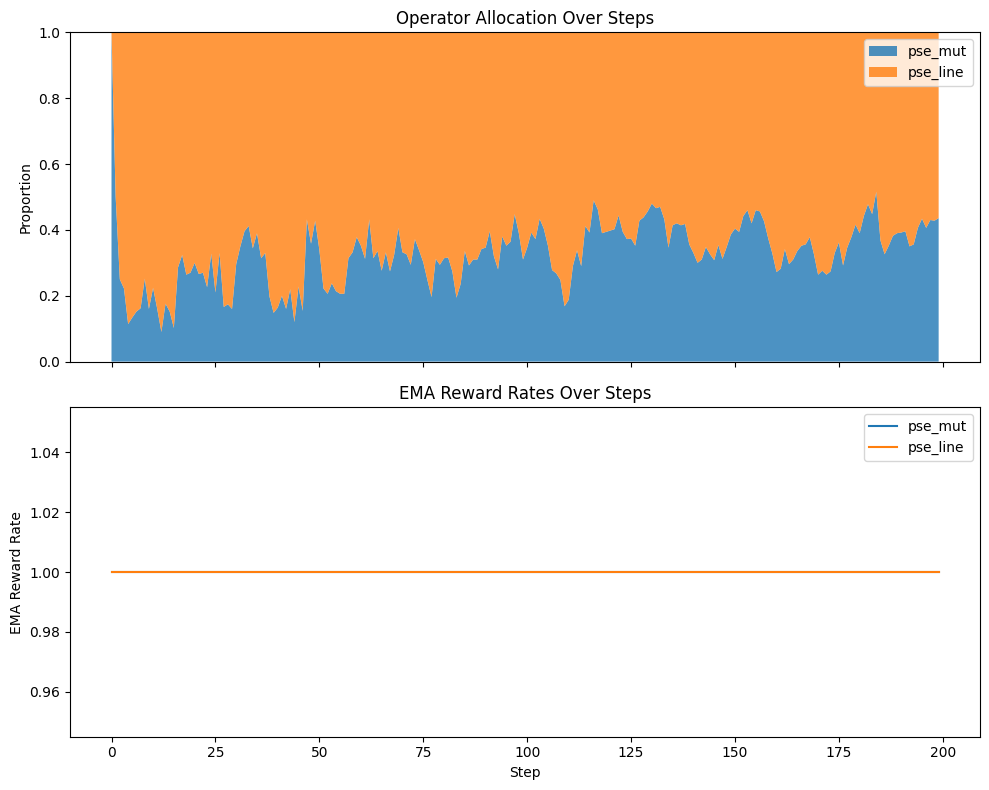

Plots saved to: /Users/frankh/Downloads/ant_gait_ckpts/Ant_MAPElite_GaussLine_BoltzMix/MAPElite_GaussLine_BoltzMix_seed123/
QD-score: 3033268.0095 | Coverage: 0.5786 | Best fitness: -242.691200

====== All runs complete ======


In [ ]:
# ============================================================
# Cell 3: Run All Experiments (2 seeds)
# Each run saves a checkpoint + plots immediately after finishing.
# ============================================================

SEEDS = [123]  # seed 42 already completed

fitness_fn = lambda info: -info['forward_sum']

all_results = []

weight_dim = MLP_Agent(ARCHITECTURE, output_activation=OUTPUT_ACTIVATION).get_weight_dim()
print(f'Weight dim: {weight_dim}')

for seed in SEEDS:
    print(f'\n========== seed={seed} ==========')

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    collector = AntOmniCollector(
        max_steps=MAX_STEPS,
        n_episodes=N_EPISODES,
        ctrl_cost_weight=CTRL_COST_WEIGHT,
        seed=seed,
    )
    bd = AntGaitBD(bin_sizes=BIN_SIZES)
    bm = MAPElitesBM(behavior_descriptor=bd, fitness_fn=fitness_fn, top_k=TOP_K, max_fitness=MAX_FITNESS)

    sp = BoltzmannMix(
        agent_class=MLP_Agent,
        architecture=ARCHITECTURE,
        agent_kwargs={'output_activation': OUTPUT_ACTIVATION},
        operators=[PSEMut(sigma=PSE_MUT_SIGMA, greedy_mem=GREEDY_MEM), PSELine(greedy_mem=GREEDY_MEM)],
        n_total=N_TOTAL,
        warmup_threshold=999999,
        ema_alpha=EMA_ALPHA,
        temperature=TEMPERATURE,
        min_proportion=MIN_PROPORTION,
    )

    me = MAPElite(search_phase=sp, collector=collector, behavior_matching=bm)
    me.run(n_steps=N_STEPS)

    # Save checkpoint immediately after this run
    ckpt_path = os.path.join(
        CKPT_BASE_DIR,
        f'MAPElite_GaussLine_BoltzMix_seed{seed}/'
    )
    save_checkpoint(ckpt_path, bm, me.history, sp=sp)
    print(f'Checkpoint saved: {ckpt_path}')

    # Save plots into checkpoint folder
    me.plot_history(save_path=ckpt_path + 'plot_history.png')
    sp.plot_allocation(save_path=ckpt_path + 'plot_allocation.png')
    print(f'Plots saved to: {ckpt_path}')

    # Print results
    f_min, f_mean, f_max = bm.fitness_stats()
    qd  = bm.qd_score()
    cov = bm.coverage()
    print(f'QD-score: {qd:.4f} | Coverage: {cov:.4f} | Best fitness: {f_min:.6f}')

    all_results.append({
        'seed': seed,
        'qd_score': qd, 'coverage': cov,
    })

print('\n====== All runs complete ======')